# Part 3: Shortcomings under Simple Implementation (Black-Scholes Framework)

### Structure
- **3.1** Evidence of Non-Constant Volatility
- **3.2** Consistent Underperformance of LS/BA
- **3.3** Implications / Bridge to SLV & UVM

### Assets
- **SPY** — Broad market baseline (S&P 500 ETF)
- **NVDA** — High volatility, strong skew (Tech)
- **TSLA** — Extreme volatility / skew (EV / Consumer)
- **JPM** — Fat tail, jump risk (Financial)

### Note
- Data layer functions are stubs — connect WRDS to activate
- Analysis and visualization layers are fully implemented
- Run `main_pipeline(data)` after loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import griddata
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Parameters

In [2]:
ASSETS = {
    'SPY':  {'secid': 109820, 'name': 'SPDR S&P 500 ETF'},
    'NVDA': {'secid': 105543, 'name': 'NVIDIA Corporation'},
    'TSLA': {'secid': 279673, 'name': 'Tesla Inc'},
    'JPM':  {'secid': 47896,  'name': 'JPMorgan Chase & Co'},
}

SNAPSHOT_DATE = '2024-01-02'

RISK_FREE_RATE = 0.0533

ATM_BAND = 0.20

---
## Layer 1: Data (WRDS)
Connect WRDS and replace stub functions with real queries.

In [3]:
def connect_wrds():
    import wrds
    return wrds.Connection(autoconnect=True)


def fetch_options(db, secid, date):
    sql = f"""
    SELECT
        date,
        exdate,
        strike_price / 1000.0 AS strike,
        cp_flag,
        best_bid,
        best_offer,
        (best_bid + best_offer) / 2.0 AS mid_price,
        impl_volatility,
        delta,
        volume
    FROM optionm.opprcd2024
    WHERE secid = {secid}
      AND date = '{date}'
      AND cp_flag = 'P'
      AND best_bid > 0
      AND best_offer > 0
      AND impl_volatility IS NOT NULL
    ORDER BY exdate, strike_price
    """
    df = db.raw_sql(sql, date_cols=['date', 'exdate'])
    df['T'] = (df['exdate'] - df['date']).dt.days / 365.0
    return df


def fetch_spot(db, secid, date):
    sql = f"""
    SELECT date, close
    FROM optionm.secprd2024
    WHERE secid = {secid}
      AND date = '{date}'
    """
    df = db.raw_sql(sql, date_cols=['date'])
    return float(df['close'].iloc[0])


def fetch_hist_prices(db, secid, start_date, end_date):
    queries = []
    if start_date <= '2023-12-31':
        queries.append(f"""
        SELECT date, close FROM optionm.secprd2023
        WHERE secid = {secid}
          AND date >= '{start_date}' AND date <= '2023-12-31'
        """)
    if end_date >= '2024-01-01':
        queries.append(f"""
        SELECT date, close FROM optionm.secprd2024
        WHERE secid = {secid}
          AND date >= '2024-01-01' AND date <= '{end_date}'
        """)
    dfs = [db.raw_sql(q, date_cols=['date']) for q in queries]
    df = pd.concat(dfs).sort_values('date').reset_index(drop=True)
    df['return'] = np.log(df['close'] / df['close'].shift(1))
    return df


def load_all_data(db):
    data = {}
    for ticker, info in ASSETS.items():
        print(f"Fetching {ticker}...")
        secid = info['secid']
        spot = fetch_spot(db, secid, SNAPSHOT_DATE)
        options = fetch_options(db, secid, SNAPSHOT_DATE)
        hist = fetch_hist_prices(db, secid, '2023-01-01', SNAPSHOT_DATE)
        options = options[
            (options['strike'] >= spot * (1 - ATM_BAND)) &
            (options['strike'] <= spot * (1 + ATM_BAND))
        ].copy()
        data[ticker] = {'spot': spot, 'options': options, 'hist': hist}
        print(f"  Spot: {spot:.2f} | Options: {len(options)} | Hist: {len(hist)} days")
    return data

---
## Layer 2: Analysis

In [4]:
def compute_rv(hist_df, horizon_days):
    horizon_days = max(int(horizon_days), 5)
    return hist_df['return'].tail(horizon_days).std() * np.sqrt(252)


def add_rv(options_df, hist_df):
    options_df = options_df.copy()
    options_df['RV'] = options_df['T'].apply(
        lambda t: compute_rv(hist_df, int(t * 252))
    )
    return options_df


def get_atm_iv_curve(options_df, spot):
    options_df = options_df.copy()
    options_df['moneyness'] = (options_df['strike'] - spot).abs()
    atm = options_df.loc[options_df.groupby('T')['moneyness'].idxmin()]
    return atm[['T', 'strike', 'impl_volatility']].sort_values('T')


def blackscholes_put(S, K, r, T, vol, q=0):
    if T <= 0 or vol <= 0:
        return max(K - S, 0)
    d1 = (np.log(S / K) + (r - q + 0.5 * vol**2) * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)
    return (K * np.exp(-r * T) * norm.cdf(-d2)
            - S * np.exp(-q * T) * norm.cdf(-d1))

---
## Layer 3: Visualization
### 3.1 — Evidence of Non-Constant Volatility

In [5]:
COLORS = {'SPY': '#2563EB', 'NVDA': '#16A34A', 'TSLA': '#DC2626', 'JPM': '#D97706'}


def plot_vol_skew(data, target_T=0.5, tol=0.1):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
    fig.suptitle(f'Volatility Skew by Asset (T ≈ {target_T}y)', fontsize=13, fontweight='bold')

    for ax, (ticker, d) in zip(axes, data.items()):
        opts = d['options']
        subset = opts[(opts['T'] >= target_T - tol) & (opts['T'] <= target_T + tol)]
        if subset.empty:
            ax.set_title(ticker)
            ax.text(0.5, 0.5, 'No data', ha='center', transform=ax.transAxes)
            continue
        moneyness = subset['strike'] / d['spot']
        ax.scatter(moneyness, subset['impl_volatility'],
                   color=COLORS[ticker], s=18, alpha=0.7)
        ax.axvline(1.0, color='gray', linestyle='--', linewidth=0.8, label='ATM')
        ax.set_title(ticker, fontweight='bold')
        ax.set_xlabel('Moneyness (K/S)')
        ax.set_ylabel('Implied Volatility')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

    plt.tight_layout()
    plt.show()


def plot_term_structure(data):
    fig, ax = plt.subplots(figsize=(8, 5))
    for ticker, d in data.items():
        atm = get_atm_iv_curve(d['options'], d['spot'])
        ax.plot(atm['T'], atm['impl_volatility'],
                marker='o', markersize=4,
                color=COLORS[ticker], label=ticker)
    ax.set_title('ATM Implied Volatility Term Structure', fontweight='bold')
    ax.set_xlabel('Time to Maturity (years)')
    ax.set_ylabel('ATM Implied Volatility')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_vol_surface(data):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4),
                              subplot_kw={'projection': '3d'})
    fig.suptitle('Implied Volatility Surface', fontsize=13, fontweight='bold')

    for ax, (ticker, d) in zip(axes, data.items()):
        opts = d['options'].dropna(subset=['impl_volatility'])
        moneyness = opts['strike'] / d['spot']
        T = opts['T']
        IV = opts['impl_volatility']

        ti = np.linspace(T.min(), T.max(), 40)
        mi = np.linspace(moneyness.min(), moneyness.max(), 40)
        TT, MM = np.meshgrid(ti, mi)
        ZZ = griddata((T, moneyness), IV, (TT, MM), method='linear')

        ax.plot_surface(MM, TT, ZZ, cmap='RdYlGn_r', alpha=0.85, edgecolor='none')
        ax.set_title(ticker, fontweight='bold')
        ax.set_xlabel('K/S', labelpad=6)
        ax.set_ylabel('T', labelpad=6)
        ax.set_zlabel('IV', labelpad=6)
        ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()


def plot_iv_vs_rv(data):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('Implied Volatility vs Realized Volatility', fontsize=13, fontweight='bold')

    for ax, (ticker, d) in zip(axes, data.items()):
        opts = add_rv(d['options'], d['hist'])
        ax.scatter(opts['RV'], opts['impl_volatility'],
                   color=COLORS[ticker], s=12, alpha=0.5)
        lims = [min(opts['RV'].min(), opts['impl_volatility'].min()) - 0.01,
                max(opts['RV'].max(), opts['impl_volatility'].max()) + 0.01]
        ax.plot(lims, lims, 'k--', linewidth=0.8, label='IV = RV')
        ax.set_title(ticker, fontweight='bold')
        ax.set_xlabel('Realized Volatility')
        ax.set_ylabel('Implied Volatility')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

def plot_vol_timeseries(data):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes = axes.flatten()
    fig.suptitle('Historical Volatility of Implied Volatility (ATM)', fontsize=13, fontweight='bold')

    for ax, (ticker, d) in zip(axes, data.items()):
        opts = d['options']
        spot = d['spot']
        atm  = get_atm_iv_curve(opts, spot)
        ax.plot(atm['T'], atm['impl_volatility'],
                color=COLORS[ticker], marker='o', markersize=4)
        ax.axhline(atm['impl_volatility'].mean(), color='gray',
                   linestyle='--', linewidth=0.9, label=f"Mean: {atm['impl_volatility'].mean():.1%}")
        ax.fill_between(atm['T'],
                        atm['impl_volatility'].mean() - atm['impl_volatility'].std(),
                        atm['impl_volatility'].mean() + atm['impl_volatility'].std(),
                        alpha=0.15, color=COLORS[ticker], label=f"±1σ: {atm['impl_volatility'].std():.1%}")
        ax.set_title(ticker, fontweight='bold')
        ax.set_xlabel('Time to Maturity (years)')
        ax.set_ylabel('ATM Implied Volatility')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### 3.2 — Consistent Underperformance of LS/BA

In [6]:
def blackscholes_mc(S=100, vol=0.2, r=0, q=0,
                    ts=np.linspace(0, 1, 13), npaths=10):
    n_steps = len(ts)
    dt = np.diff(ts)
    paths = np.zeros((n_steps, npaths))
    paths[0] = S
    for i, dti in enumerate(dt):
        Z = np.random.standard_normal(npaths)
        paths[i+1] = paths[i] * np.exp(
            (r - q - 0.5 * vol**2) * dti + vol * np.sqrt(dti) * Z
        )
    return paths


def regression_polynomial(X, Y, S_current, degree=3, **kwargs):
    coeffs = np.polyfit(X, Y, degree)
    cont_value = np.polyval(coeffs, S_current)
    model = {'type': 'polynomial', 'coeffs': coeffs}
    return cont_value, model


def ls_pricer(paths, K, r, ts, regression_func, **regression_params):
    n_steps, n_paths = paths.shape
    payoff = np.maximum(K - paths[-1], 0)
    policy = {'models': []}

    for i in range(n_steps - 2, 0, -1):
        discount = np.exp(-r * (ts[i+1] - ts[i]))
        payoff_discounted = payoff * discount
        exercise_value = np.maximum(K - paths[i], 0)
        tau = ts[-1] - ts[i]
        cont_value, model = regression_func(
            paths[i], payoff_discounted, paths[i],
            K=K, r=r, tau=tau, **regression_params
        )
        policy['models'].insert(0, model)
        exercise_mask = exercise_value > cont_value
        payoff_new = payoff_discounted.copy()
        payoff_new[exercise_mask] = exercise_value[exercise_mask]
        payoff = payoff_new

    price = np.mean(payoff * np.exp(-r * (ts[1] - ts[0])))
    return price, policy


def exer_or_cont(i, S, models, K, r, ts):
    S = np.atleast_1d(S)
    if i >= len(ts) - 1:
        return np.maximum(K - S, 0) > 0
    if i < 1 or i - 1 >= len(models):
        return np.zeros(len(S), dtype=bool)
    model = models[i - 1]
    exercise_value = np.maximum(K - S, 0)
    cont_value = np.polyval(model['coeffs'], S)
    return exercise_value > cont_value


def nested_mc(S, vol, r, q, i, ts, nnested, models, K):
    nested_paths = np.full(nnested, S, dtype=float)
    tot_payoff = 0
    for j in range(i+1, len(ts)):
        dt = ts[j] - ts[j-1]
        dW = np.random.randn(len(nested_paths)) * np.sqrt(dt)
        nested_paths = nested_paths * np.exp((r - q) * dt) * np.exp(-0.5 * vol**2 * dt + vol * dW)
        exer_vals = np.maximum(K - nested_paths, 0)
        if j < len(ts) - 1:
            ind = exer_or_cont(j, nested_paths, models, K, r, ts)
            tot_payoff += np.sum(exer_vals[ind]) * np.exp(-r * ts[j])
            nested_paths = nested_paths[~ind]
            if len(nested_paths) == 0:
                break
        else:
            tot_payoff += np.sum(exer_vals) * np.exp(-r * ts[j])
    return tot_payoff / nnested


def price_asset(spot, vol, r, T, K=None, q=0,
                n_steps=12, n_train=50000, n_ba=500, n_nested=500, seed=42, degree=3):
    np.random.seed(seed)
    if K is None:
        K = spot
    ts = np.linspace(0, T, n_steps + 1)
    exer_func = lambda S: np.maximum(K - S, 0)

    paths_train = blackscholes_mc(S=spot, vol=vol, r=r, q=q, ts=ts, npaths=n_train)
    lower, policy = ls_pricer(paths_train, K, r, ts, regression_polynomial, degree=degree)
    models = policy['models']

    paths_ba = blackscholes_mc(S=spot, vol=vol, r=r, q=q, ts=ts, npaths=n_ba)
    V  = np.full(paths_ba.shape, np.nan, dtype=float)
    EV = np.full(paths_ba.shape, np.nan, dtype=float)
    V[0]  = lower
    EV[0] = lower

    for i in range(1, len(ts) - 1):
        exer_vals = exer_func(paths_ba[i])
        ind = exer_or_cont(i, paths_ba[i], models, K, r, ts)
        for j in np.nonzero(ind)[0]:
            V[i, j]  = exer_vals[j] * np.exp(-r * ts[i])
            EV[i, j] = nested_mc(paths_ba[i, j], vol, r, q, i, ts, n_nested, models, K)
        for j in np.nonzero(~ind)[0]:
            V[i, j]  = nested_mc(paths_ba[i, j], vol, r, q, i, ts, n_nested, models, K)
            EV[i, j] = V[i, j]

    V[-1] = exer_func(paths_ba[-1]) * np.exp(-r * ts[-1])
    hedges = np.zeros(paths_ba.shape, dtype=float)
    hedges[1:] = np.cumsum(V[1:] - EV[:-1], axis=0)

    upper = float(np.mean(
        np.amax(exer_func(paths_ba[1:]) * np.exp(-r * ts[1:, np.newaxis]) - hedges[1:], axis=0)
    ))
    return lower, upper

In [7]:
def plot_model_vs_market(results):
    tickers = list(results.keys())
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.suptitle('Model Bounds vs Market Price (ATM Put)', fontsize=13, fontweight='bold')

    for ax, ticker in zip(axes, tickers):
        r = results[ticker]
        vals = [r['lower'], r['upper'], r['market']]
        labels = ['LSM Lower', 'BA Upper', 'Market']
        colors = [COLORS[ticker], COLORS[ticker], '#1e1e2e']
        alphas = [0.5, 0.8, 0.85]

        bars = ax.bar(labels, vals, color=colors,
                      alpha=0.8, width=0.5)
        for bar, alpha in zip(bars, alphas):
            bar.set_alpha(alpha)

        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (max(vals) - min(vals)) * 0.02,
                    f'{val:.2f}',
                    ha='center', va='bottom', fontsize=8)

        margin = (max(vals) - min(vals)) * 1.5
        ax.set_ylim(min(vals) - margin, max(vals) + margin)
        ax.set_title(ticker, fontweight='bold')
        ax.set_ylabel('Option Price ($)')

    plt.tight_layout()
    plt.show()


def plot_sensitivity_multi(data, ticker='SPY'):
    d    = data[ticker]
    spot = d['spot']
    opts = d['options']
    atm  = opts[(opts['strike'] - spot).abs() < spot * 0.02]
    row  = atm.sort_values('T').iloc[len(atm)//2]
    K    = row['strike']
    T    = row['T']
    vol  = compute_rv(d['hist'], 252)
    mkt  = row['mid_price']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{ticker} — Parameter Sensitivity (ATM Put)', fontweight='bold')

    params = [
        ('q', [0, 0.005, 0.01, 0.015, 0.02], {'r': RISK_FREE_RATE, 'vol_fixed': vol}),
        ('r', [0.02, 0.03, 0.04, 0.05, 0.06, 0.07], {'q': 0, 'vol_fixed': vol}),
        ('vol', [vol*0.7, vol*0.85, vol, vol*1.15, vol*1.3], {'r': RISK_FREE_RATE, 'q': 0}),
    ]

    for ax, (param_name, param_values, fixed) in zip(axes, params):
        lowers, uppers = [], []
        for val in param_values:
            if param_name == 'q':
                lo, up = price_asset(spot, fixed['vol_fixed'], fixed['r'], T, K=K, q=val)
            elif param_name == 'r':
                lo, up = price_asset(spot, fixed['vol_fixed'], val, T, K=K, q=fixed['q'])
            else:
                lo, up = price_asset(spot, val, fixed['r'], T, K=K, q=fixed['q'])
            lowers.append(lo)
            uppers.append(up)

        ax.plot(param_values, lowers, marker='o', label='LSM Lower', color='#2563EB')
        ax.plot(param_values, uppers, marker='s', label='BA Upper',  color='#16A34A')
        ax.fill_between(param_values, lowers, uppers, alpha=0.15, color='gray')
        ax.axhline(mkt, color='#DC2626', linestyle='--', linewidth=1, label=f'Market ({mkt:.2f})')
        ax.set_xlabel(param_name)
        ax.set_ylabel('Price ($)')
        ax.set_title(f'Sensitivity: {param_name}', fontweight='bold')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_pricing_error_across_strikes(data, ticker, r, n_train=10000):
    d = data[ticker]
    spot = d['spot']
    opts = d['options']

    T_target = opts['T'].median()
    tol = 0.05
    subset = opts[(opts['T'] >= T_target - tol) & (opts['T'] <= T_target + tol)]
    subset = subset.sort_values('strike')

    errors = []
    for _, row in subset.iterrows():
        vol = compute_rv(d['hist'], 252)
        K   = row['strike']
        mkt = row['mid_price']
        if pd.isna(vol) or vol <= 0:
            continue
        lo, up = price_asset(spot, vol, r, row['T'], K=K, n_train=n_train)
        errors.append({'strike': K, 'lower': lo, 'upper': up, 'market': mkt,
                       'error_pct': (up - mkt) / mkt * 100})

    err_df = pd.DataFrame(errors)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{ticker} — Pricing Error Across Strikes (T ≈ {T_target:.2f}y)',
                 fontweight='bold')

    axes[0].plot(err_df['strike'], err_df['market'], 'k-o', markersize=4, label='Market')
    axes[0].fill_between(err_df['strike'], err_df['lower'], err_df['upper'],
                         alpha=0.3, color=COLORS[ticker], label='Model [Lower, Upper]')
    axes[0].set_xlabel('Strike ($)')
    axes[0].set_ylabel('Option Price ($)')
    axes[0].set_title('Price Comparison')
    axes[0].legend()

    axes[1].bar(err_df['strike'], err_df['error_pct'],
                color=COLORS[ticker], alpha=0.7, width=2)
    axes[1].axhline(0, color='k', linewidth=0.8)
    axes[1].set_xlabel('Strike ($)')
    axes[1].set_ylabel('(Upper - Market) / Market (%)')
    axes[1].set_title('Relative Pricing Error')

    plt.tight_layout()
    plt.show()
    return err_df


def plot_method_comparison(data, ticker='SPY'):
    d    = data[ticker]
    spot = d['spot']
    opts = d['options']
    atm  = opts[(opts['strike'] - spot).abs() < spot * 0.02]
    row  = atm.sort_values('T').iloc[len(atm)//2]
    K    = row['strike']
    T    = row['T']
    vol  = compute_rv(d['hist'], 252)
    mkt  = row['mid_price']

    degrees = [2, 3, 5, 7]
    lowers_deg, uppers_deg = [], []
    for deg in degrees:
        lo, up = price_asset(spot, vol, RISK_FREE_RATE, T, K=K, degree=deg)
        lowers_deg.append(lo)
        uppers_deg.append(up)

    n_steps_list = [6, 12, 24]
    lowers_ts, uppers_ts = [], []
    for n_steps in n_steps_list:
        lo, up = price_asset(spot, vol, RISK_FREE_RATE, T, K=K, n_steps=n_steps)
        lowers_ts.append(lo)
        uppers_ts.append(up)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{ticker} — Method Variation: Gap Persists Across All Configurations',
                 fontweight='bold')

    axes[0].plot(degrees, lowers_deg, marker='o', label='LSM Lower', color='#2563EB')
    axes[0].plot(degrees, uppers_deg, marker='s', label='BA Upper',  color='#16A34A')
    axes[0].fill_between(degrees, lowers_deg, uppers_deg, alpha=0.15, color='gray')
    axes[0].axhline(mkt, color='#DC2626', linestyle='--', linewidth=1.2,
                    label=f'Market ({mkt:.2f})')
    all_deg = lowers_deg + uppers_deg + [mkt]
    margin_deg = (max(all_deg) - min(all_deg)) * 0.5
    axes[0].set_ylim(min(all_deg) - margin_deg, max(all_deg) + margin_deg)
    axes[0].set_xticks(degrees)
    axes[0].set_xticklabels([f'deg={d}' for d in degrees])
    axes[0].set_xlabel('Polynomial Degree')
    axes[0].set_ylabel('Option Price ($)')
    axes[0].set_title('Varying Polynomial Degree', fontweight='bold')
    axes[0].legend(fontsize=8)

    axes[1].plot(n_steps_list, lowers_ts, marker='o', label='LSM Lower', color='#2563EB')
    axes[1].plot(n_steps_list, uppers_ts, marker='s', label='BA Upper',  color='#16A34A')
    axes[1].fill_between(n_steps_list, lowers_ts, uppers_ts, alpha=0.15, color='gray')
    axes[1].axhline(mkt, color='#DC2626', linestyle='--', linewidth=1.2,
                    label=f'Market ({mkt:.2f})')
    all_ts = lowers_ts + uppers_ts + [mkt]
    margin_ts = (max(all_ts) - min(all_ts)) * 0.5
    axes[1].set_ylim(min(all_ts) - margin_ts, max(all_ts) + margin_ts)
    axes[1].set_xticks(n_steps_list)
    axes[1].set_xticklabels([f'n_steps={n}' for n in n_steps_list])
    axes[1].set_xlabel('Number of Time Steps')
    axes[1].set_ylabel('Option Price ($)')
    axes[1].set_title('Varying Time Steps', fontweight='bold')
    axes[1].legend(fontsize=8)

    plt.tight_layout()

    plt.show()

In [8]:
db = connect_wrds()

secid_check_sql = """
SELECT secid, ticker
FROM optionm.securd
WHERE ticker IN ('SPY', 'NVDA', 'TSLA', 'JPM')
"""
secid_df = db.raw_sql(secid_check_sql)
print(secid_df)

secid_df = db.raw_sql(secid_check_sql)
print("Verified secids:")
print(secid_df)

for _, row in secid_df.iterrows():
    ticker = row['ticker']
    if ticker in ASSETS:
        if ASSETS[ticker]['secid'] != int(row['secid']):
            print(f"secid mismatch for {ticker}: expected {ASSETS[ticker]['secid']}, got {int(row['secid'])} — updating")
            ASSETS[ticker]['secid'] = int(row['secid'])

ASSETS['SPY']['secid']  = 109820 
ASSETS['NVDA']['secid'] = 108321
ASSETS['JPM']['secid']  = 102936
ASSETS['TSLA']['secid'] = 143439

data = load_all_data(db)


WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
      secid ticker
0  102936.0    JPM
1  108321.0   NVDA
2    7571.0    SPY
3  100155.0    SPY
4  109820.0    SPY
5  115101.0    SPY
6  143439.0   TSLA
Verified secids:
      secid ticker
0  102936.0    JPM
1  108321.0   NVDA
2    7571.0    SPY
3  100155.0    SPY
4  109820.0    SPY
5  115101.0    SPY
6  143439.0   TSLA
secid mismatch for JPM: expected 47896, got 102936 — updating
secid mismatch for NVDA: expected 105543, got 108321 — updating
secid mismatch for SPY: expected 109820, got 7571 — updating
secid mismatch for SPY: expected 7571, got 100155 — updating
secid mismatch for SPY: expected 100155, got 109820 — updating
secid mismatch for SPY: expected 109820, got 115101 — updating
secid mismatch for TSLA: expected 279673, got 143439 — updating
Fetching SPY...
  Spot: 472.65 | Options: 2636 |

---
## Main Pipeline
Run this cell after loading data from WRDS.

In [9]:
def main_pipeline(data):

    print("=" * 60)
    print("3.1 — Evidence of Non-Constant Volatility")
    print("=" * 60)

    plot_vol_skew(data, target_T=0.5)
    plot_term_structure(data)
    plot_vol_surface(data)
    plot_iv_vs_rv(data)

    print("=" * 60)
    print("3.2 — Consistent Underperformance of LS/BA")
    print("=" * 60)

    results_market = {}
    for ticker, d in data.items():
        spot = d['spot']
        opts = d['options']
        atm  = opts[(opts['strike'] - spot).abs() < spot * 0.02]
        if atm.empty:
            print(f"{ticker}: no ATM options found, skipping")
            continue
        row  = atm.sort_values('T').iloc[len(atm)//2]
        K    = row['strike']
        T    = row['T']
        vol  = compute_rv(d['hist'], 252)
        mkt  = row['mid_price']
        
        lo, up = price_asset(spot, vol, RISK_FREE_RATE, T, K=K)
        results_market[ticker] = {'lower': lo, 'upper': up, 'market': mkt,
                                  'valid': lo < mkt < up}
        print(f"{ticker}: Lower={lo:.4f}  Upper={up:.4f}  Market={mkt:.4f}  "
              f"Valid={'✓' if lo < mkt < up else '✗'}")

    plot_model_vs_market(results_market)

    for ticker in data.keys():
        plot_sensitivity_multi(data, ticker=ticker)

    for ticker in data.keys():
        print(f"\nPricing error across strikes — {ticker} (this may take a few minutes)")
        err_df = plot_pricing_error_across_strikes(data, ticker, RISK_FREE_RATE)

    print("\nMethod variation check...")
    for ticker in data.keys():
        plot_method_comparison(data, ticker=ticker)

    return results_market, err_df


print("Pipeline ready. Connect WRDS and run:")
print("  db   = connect_wrds()")
print("  data = load_all_data(db)")
print("  results, err_df = main_pipeline(data)")

Pipeline ready. Connect WRDS and run:
  db   = connect_wrds()
  data = load_all_data(db)
  results, err_df = main_pipeline(data)


3.1 — Evidence of Non-Constant Volatility


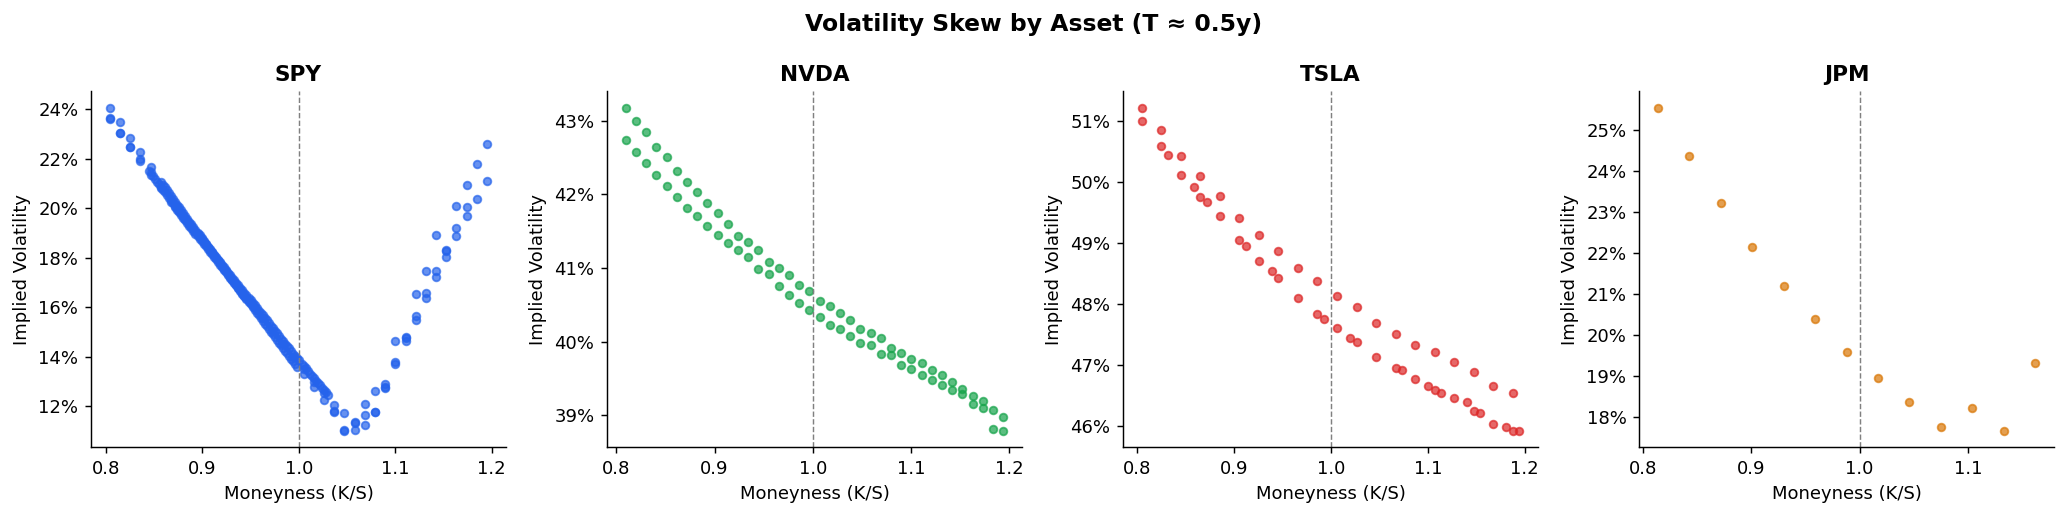

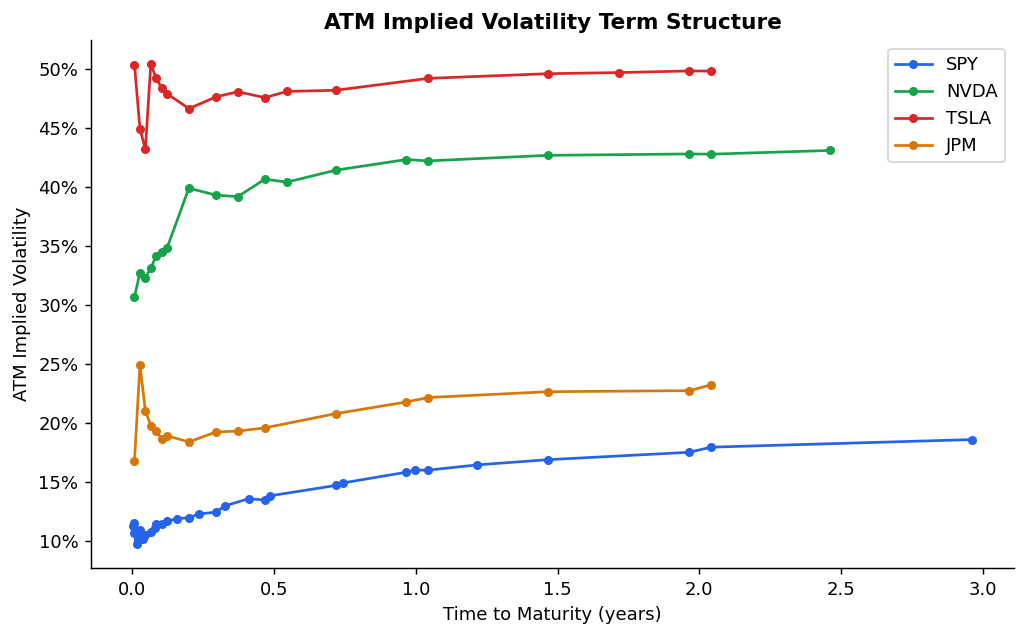

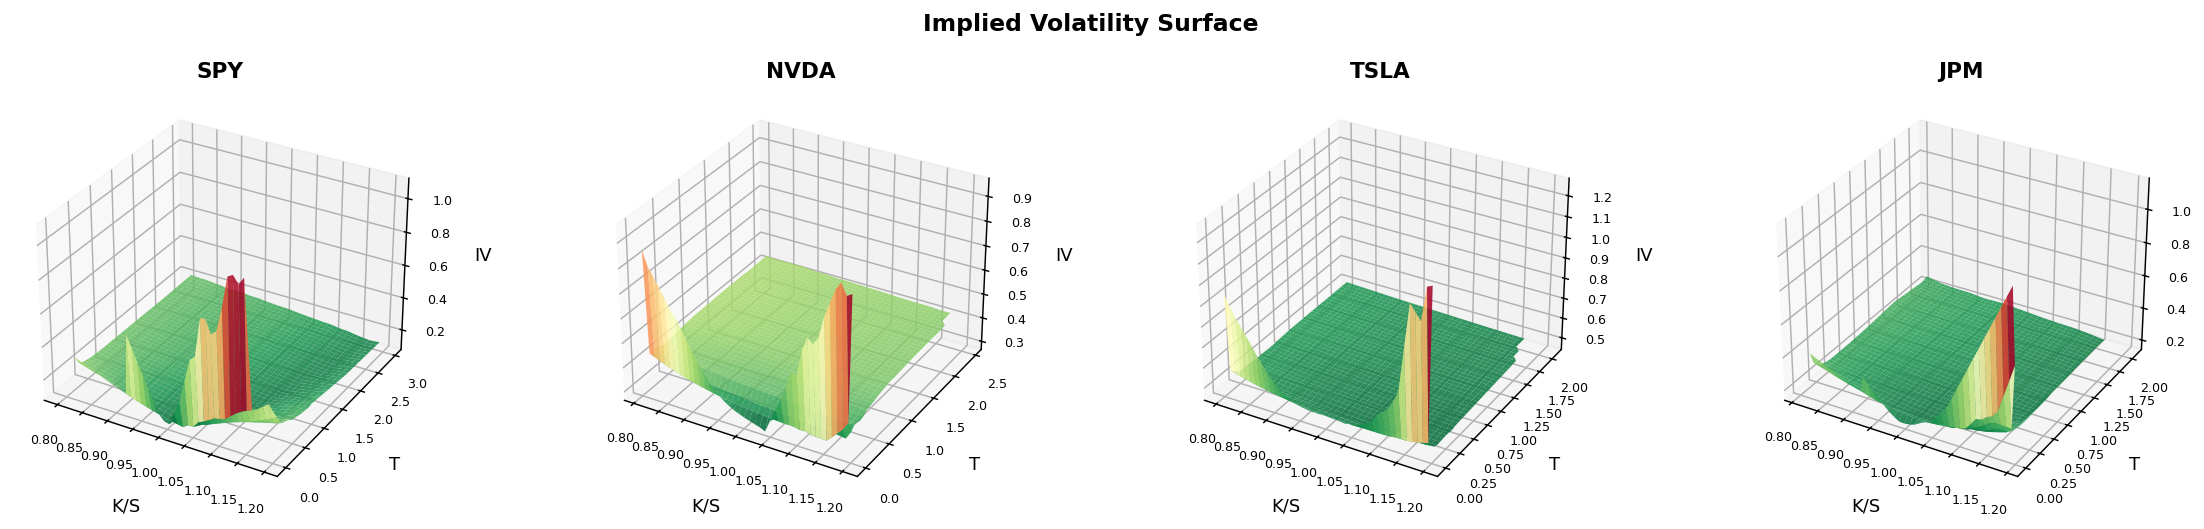

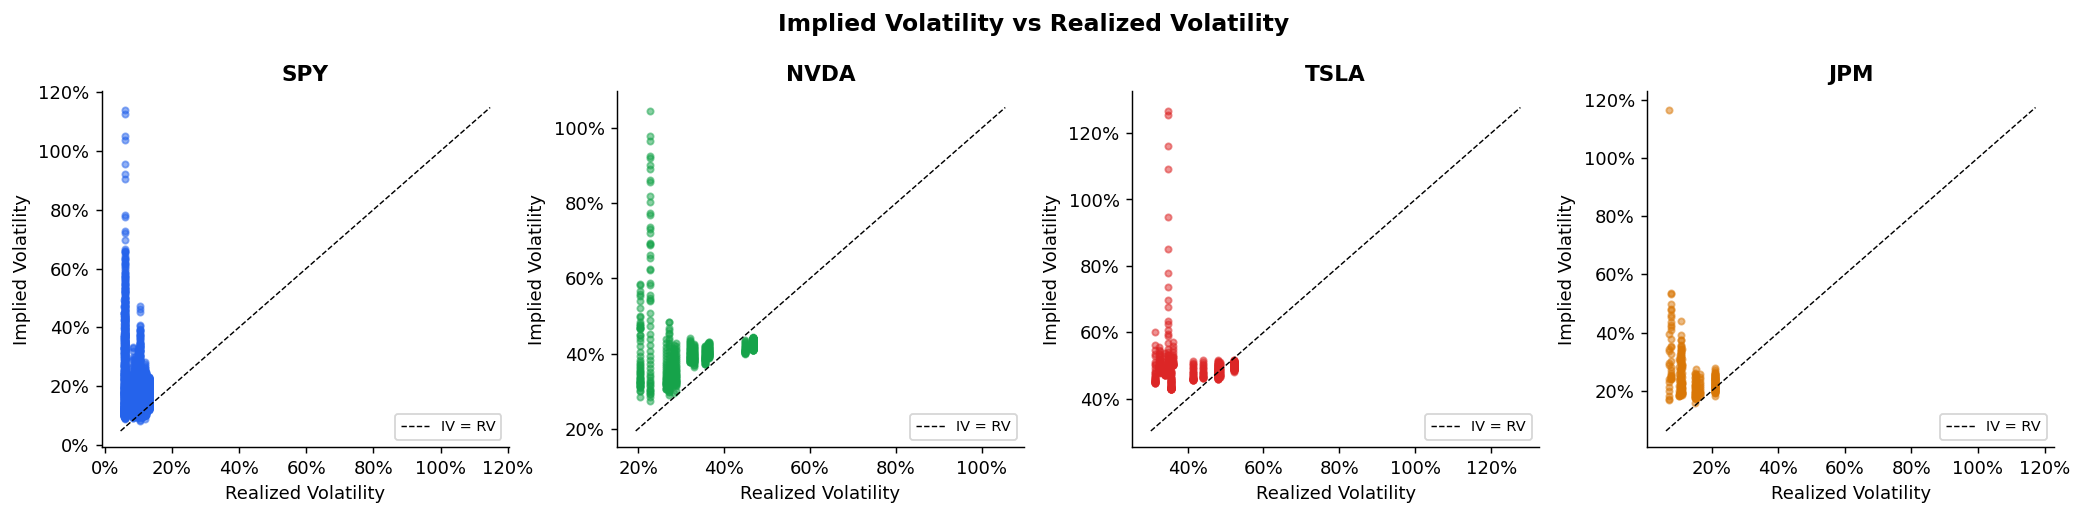

3.2 — Consistent Underperformance of LS/BA
SPY: Lower=7.4781  Upper=7.6612  Market=6.4450  Valid=✗
NVDA: Lower=39.1340  Upper=40.1031  Market=33.6000  Valid=✗
TSLA: Lower=15.4958  Upper=15.9238  Market=14.2750  Valid=✗
JPM: Lower=4.6288  Upper=4.7436  Market=4.4000  Valid=✗


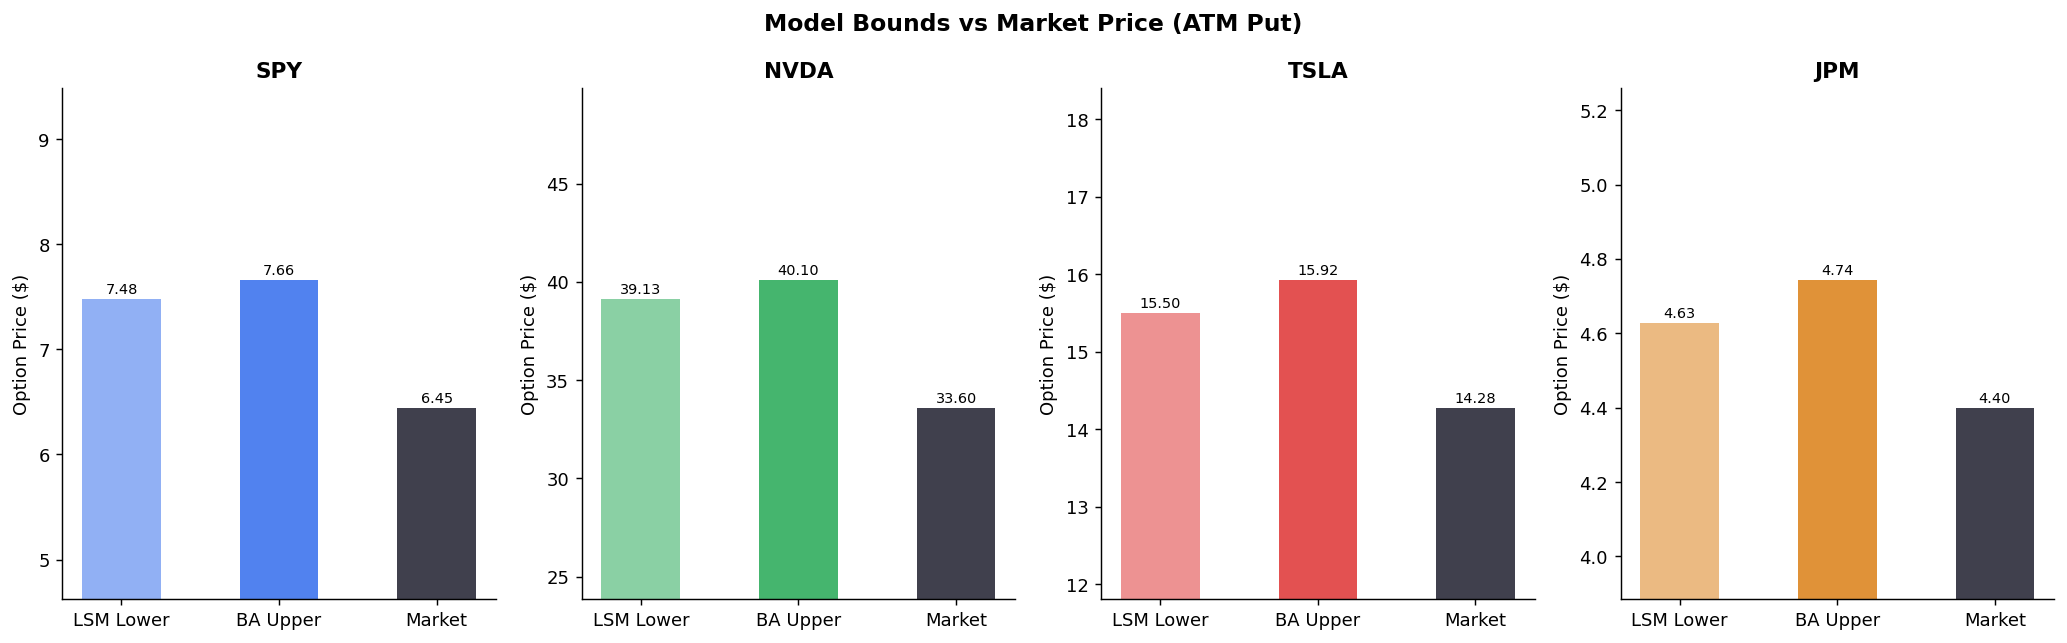

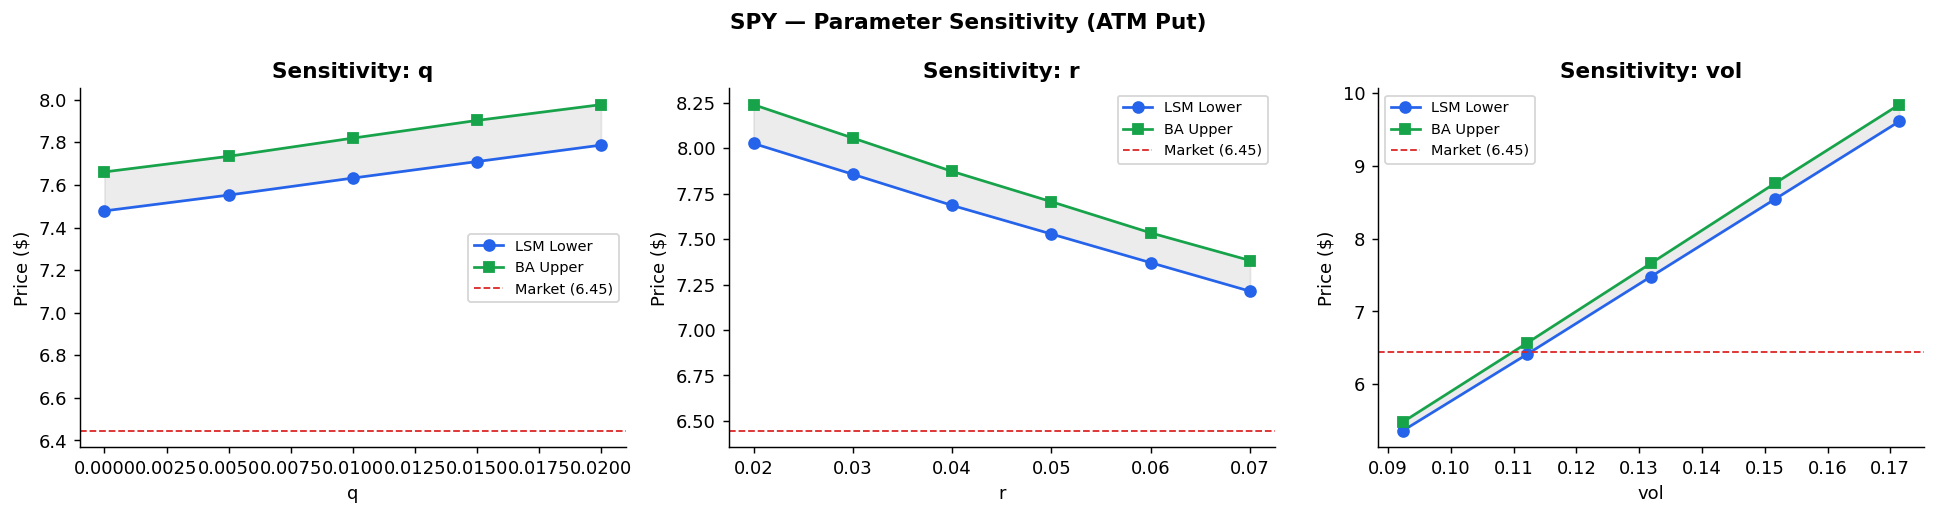

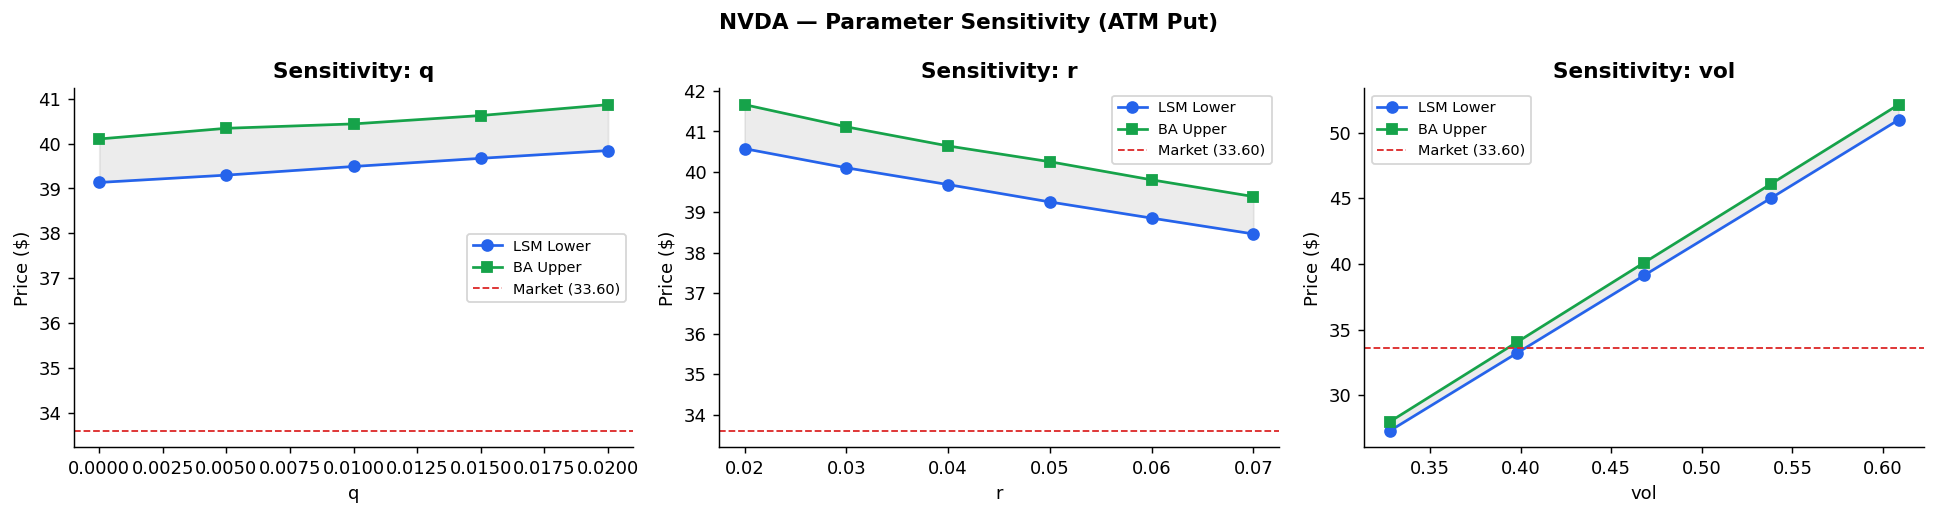

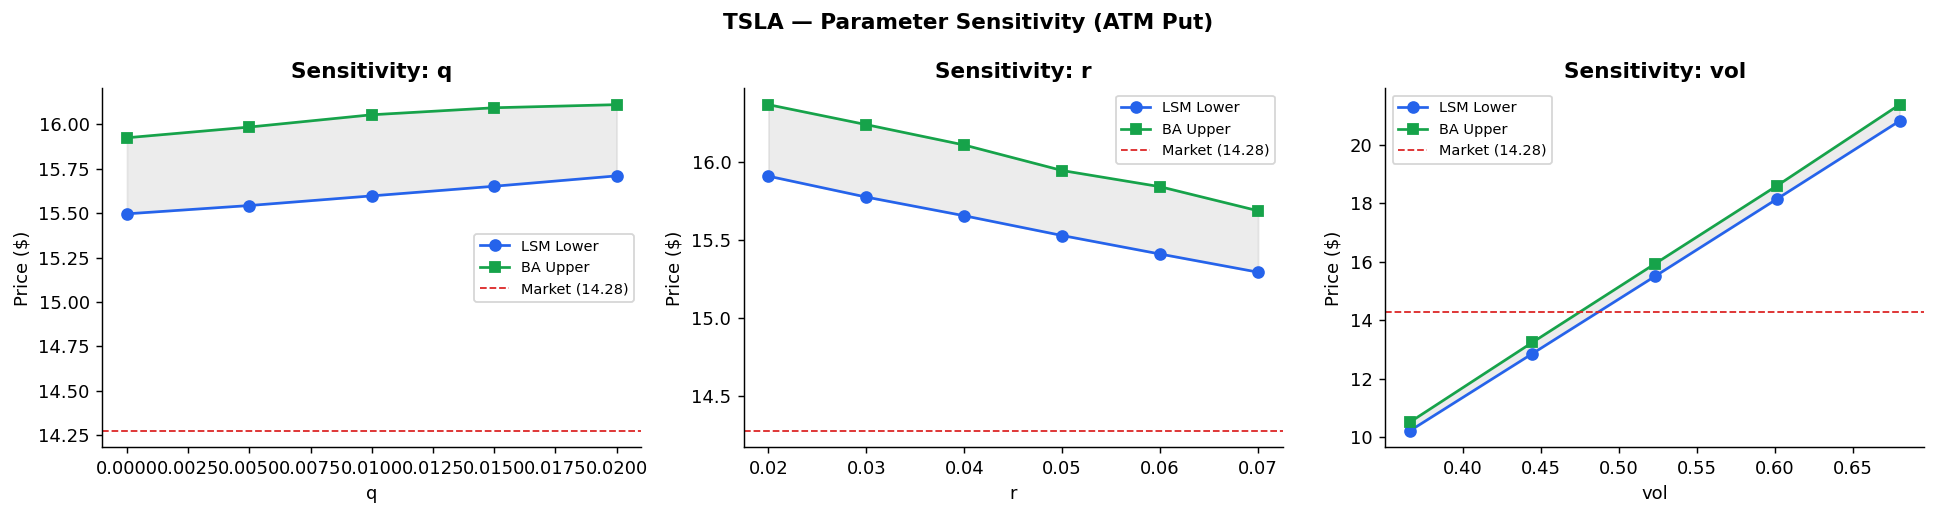

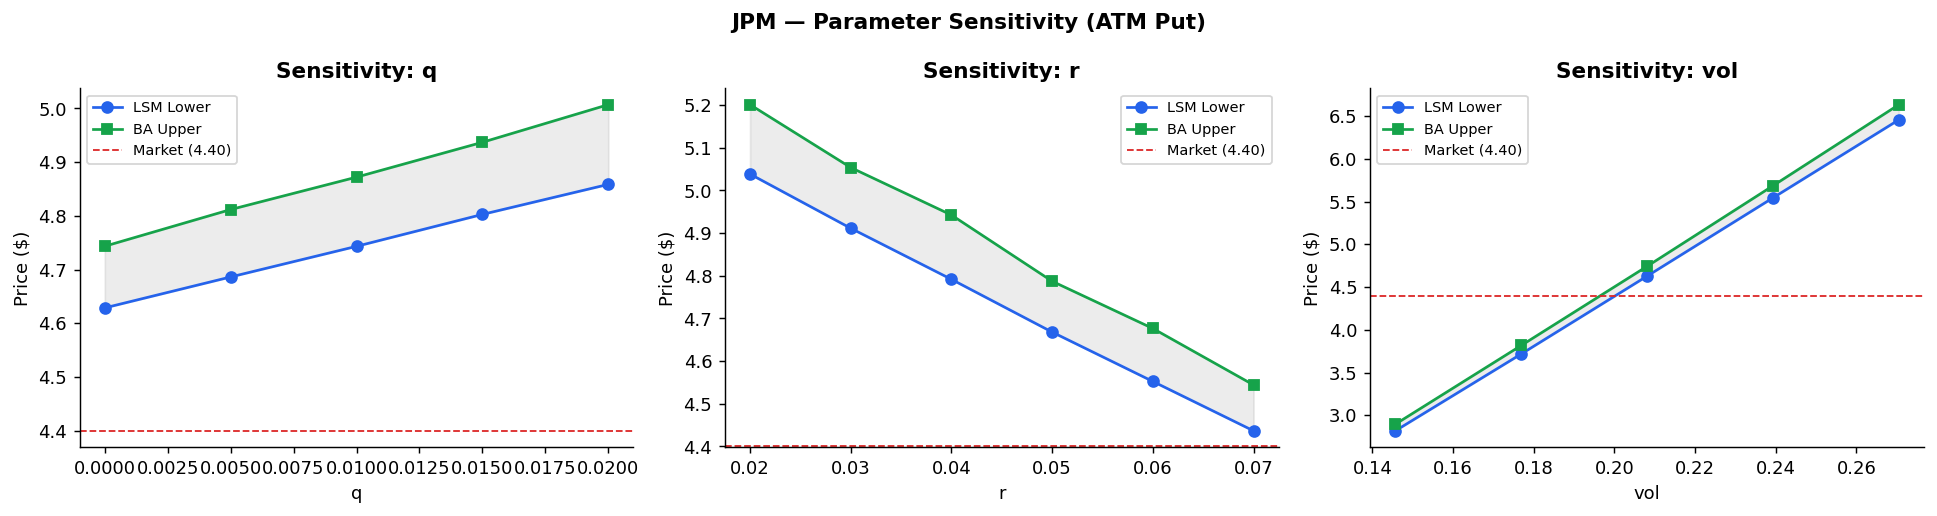


Pricing error across strikes — SPY (this may take a few minutes)


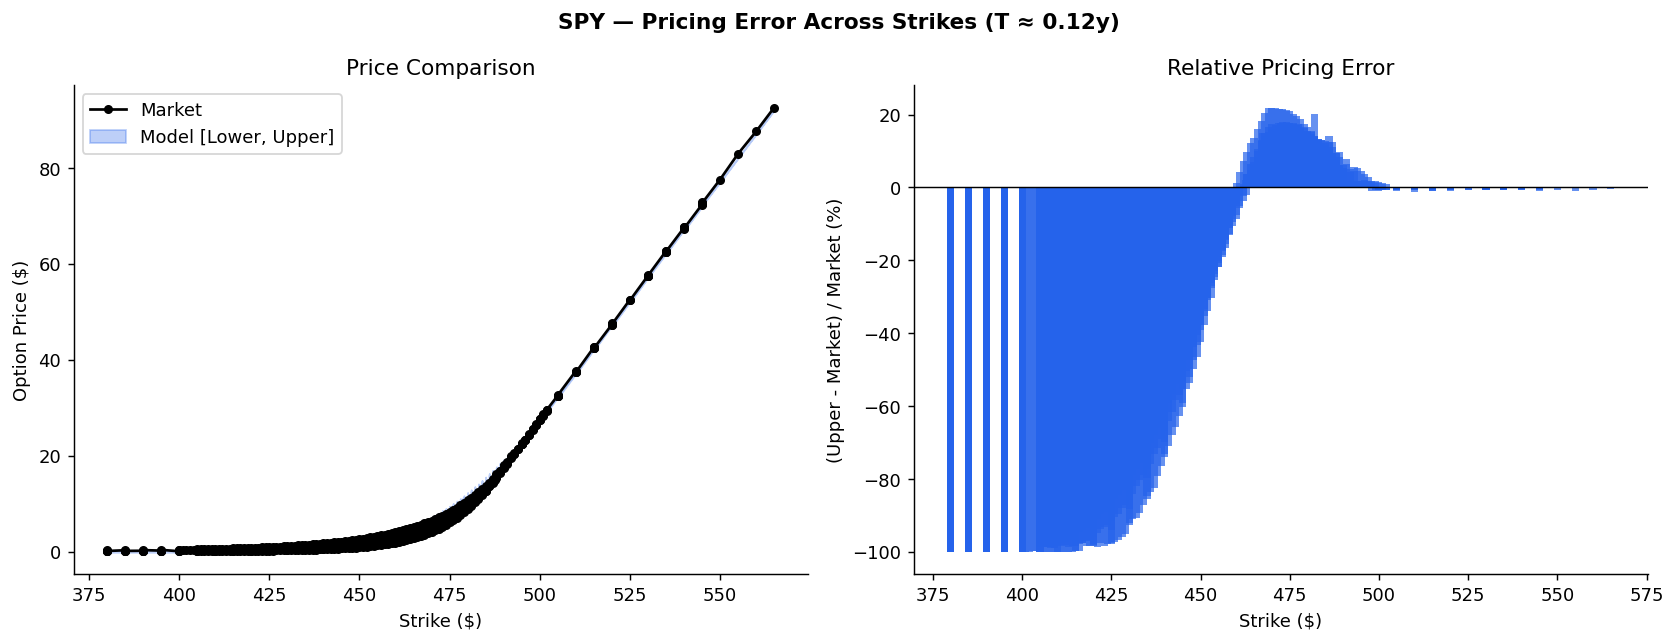


Pricing error across strikes — NVDA (this may take a few minutes)


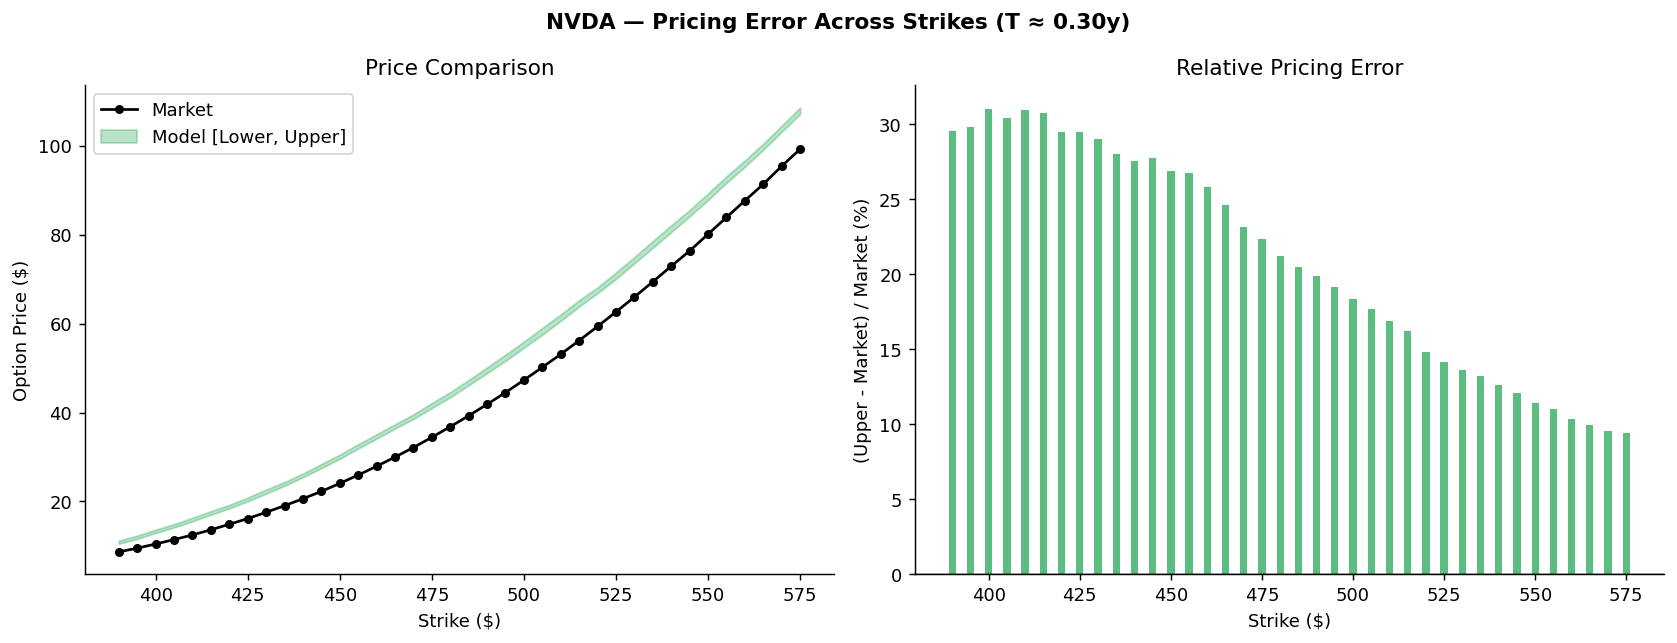


Pricing error across strikes — TSLA (this may take a few minutes)


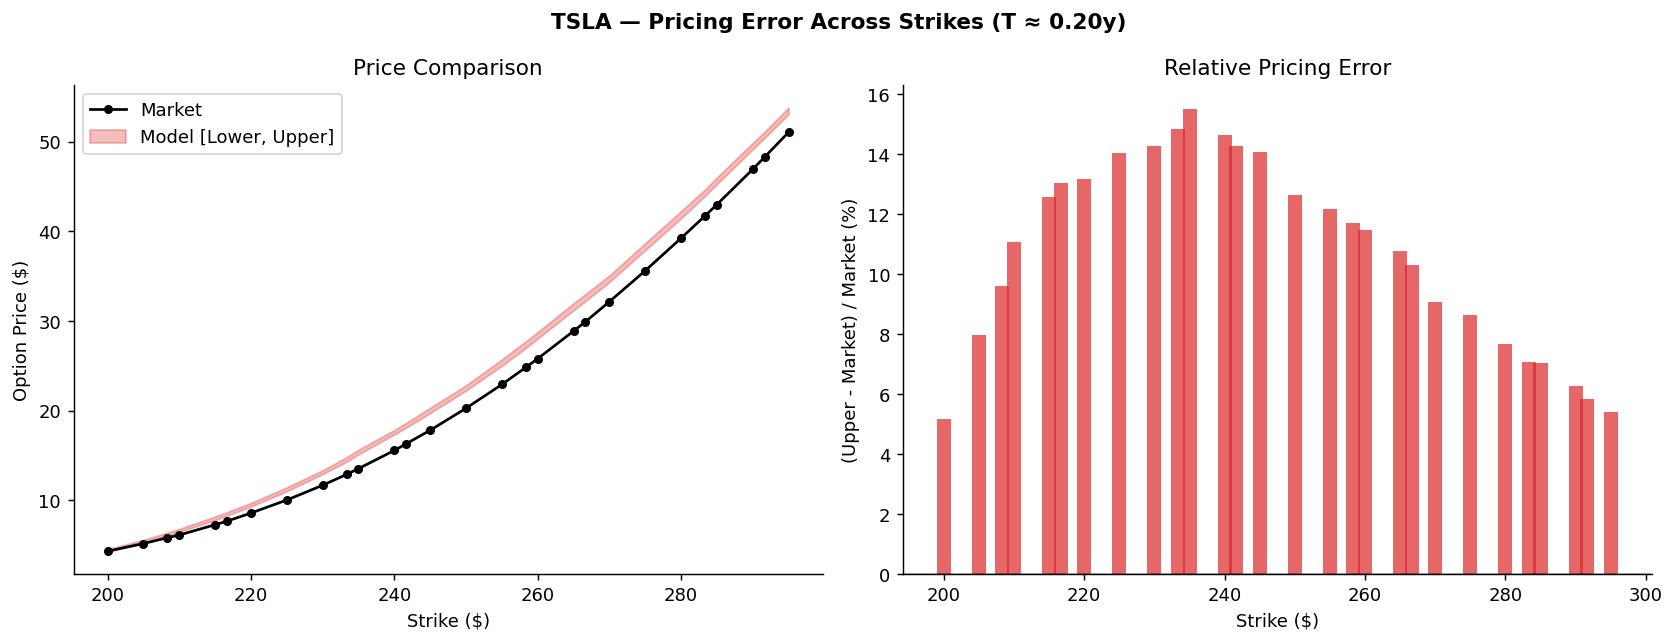


Pricing error across strikes — JPM (this may take a few minutes)


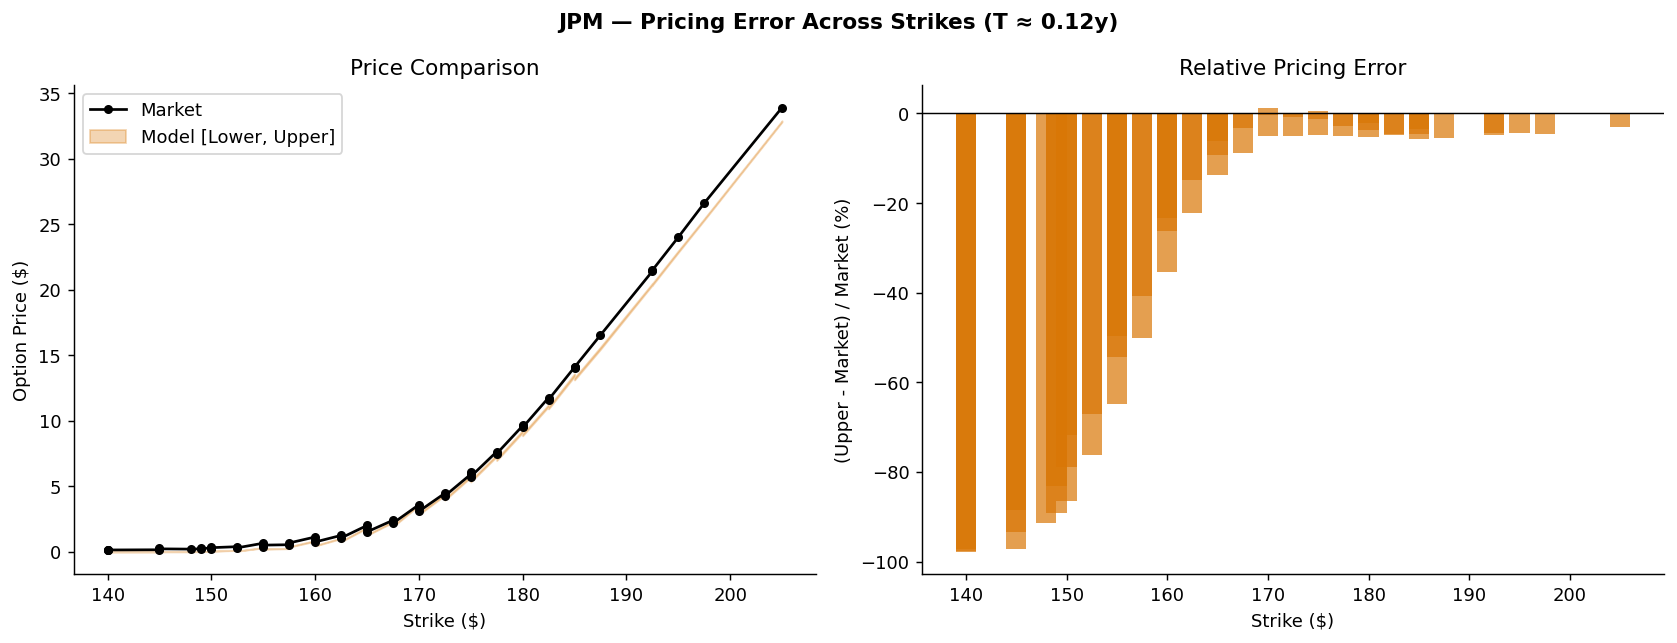


Method variation check...


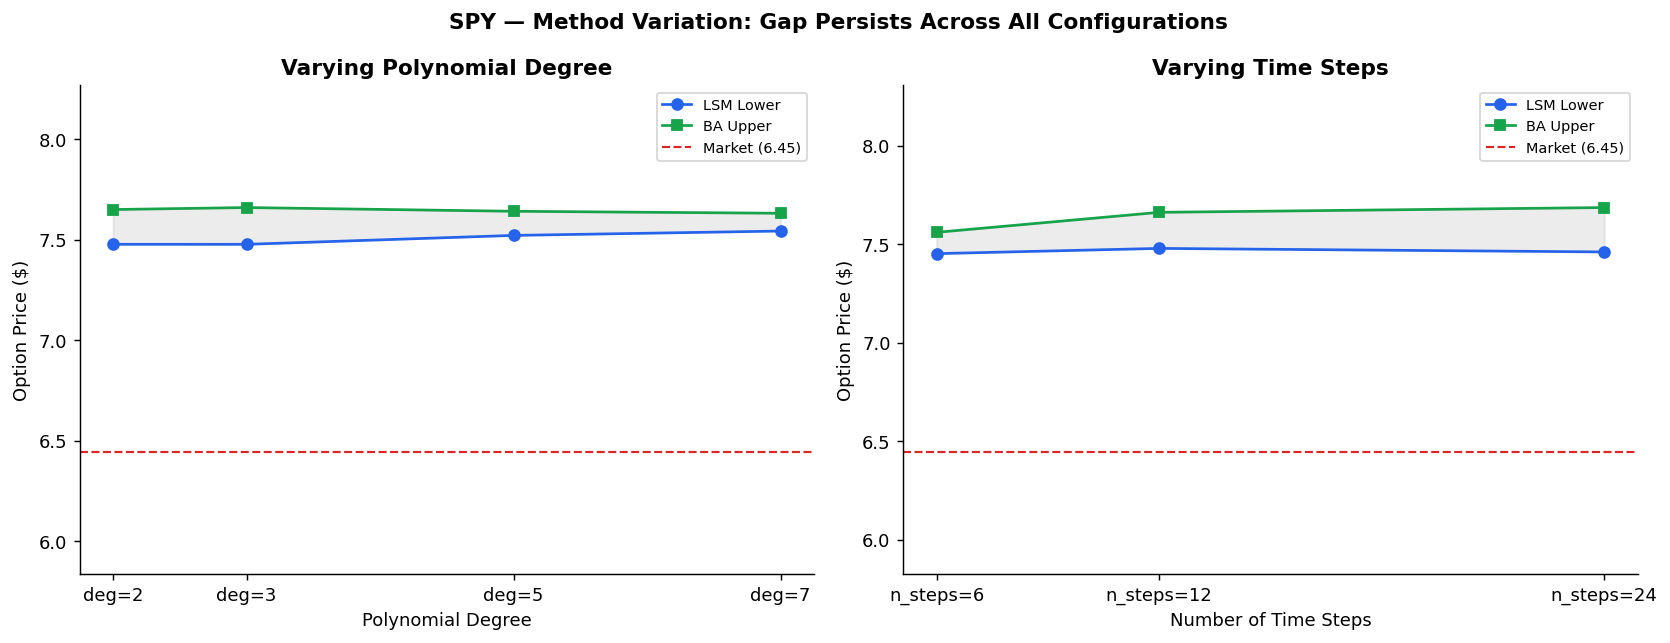

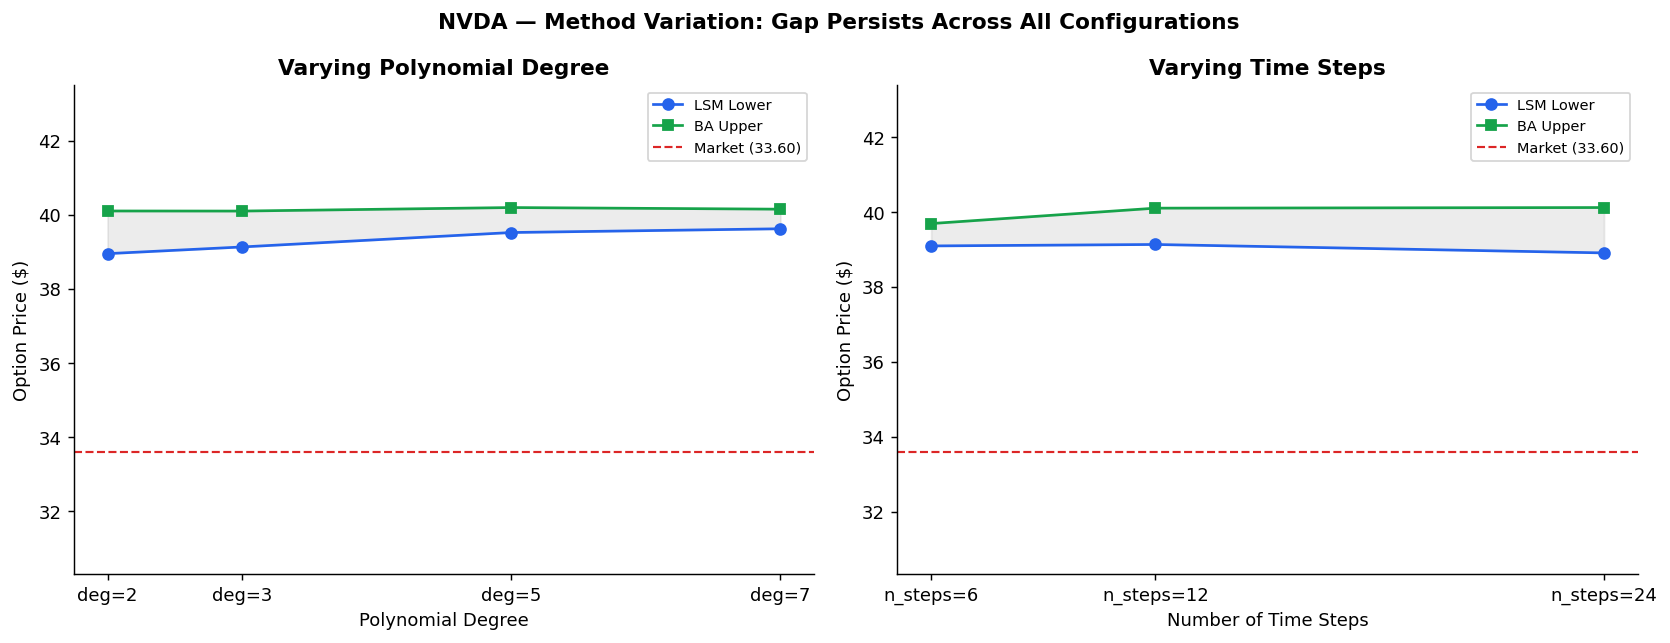

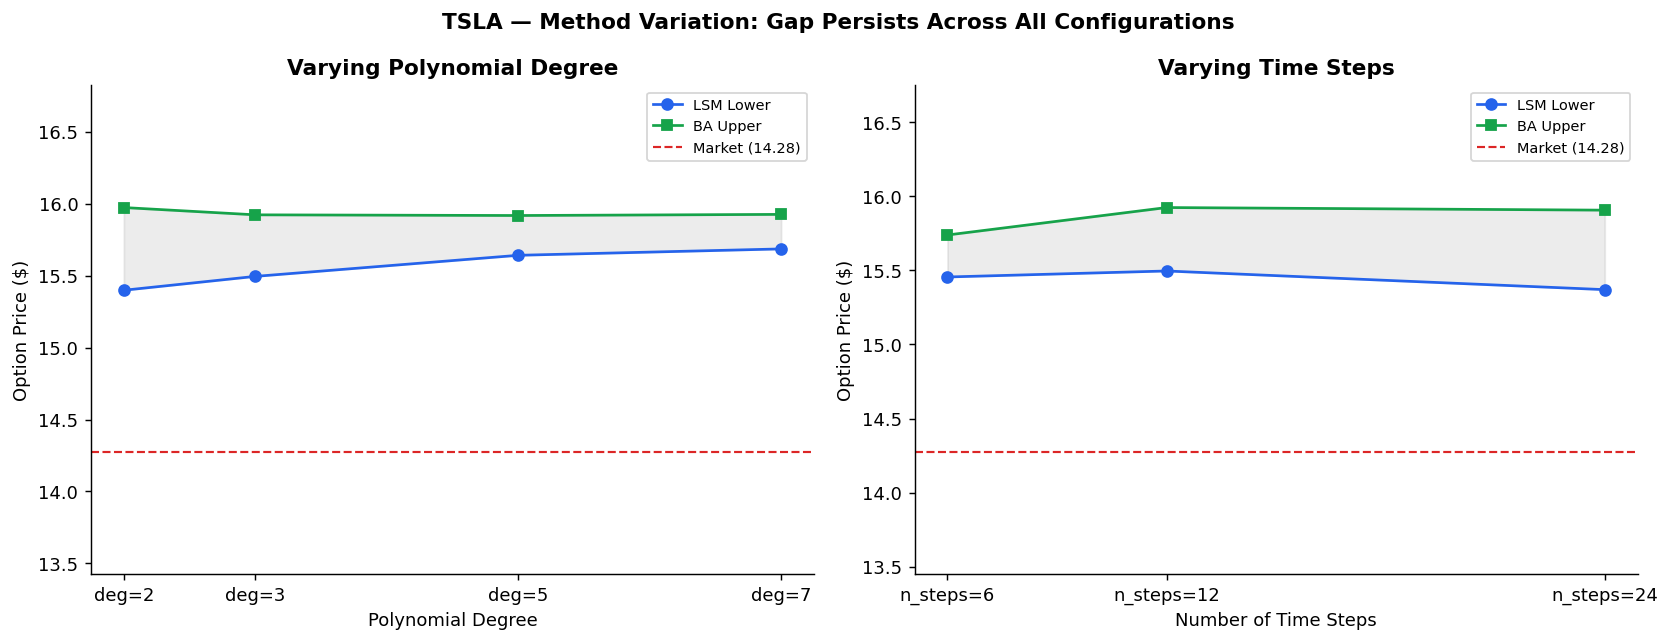

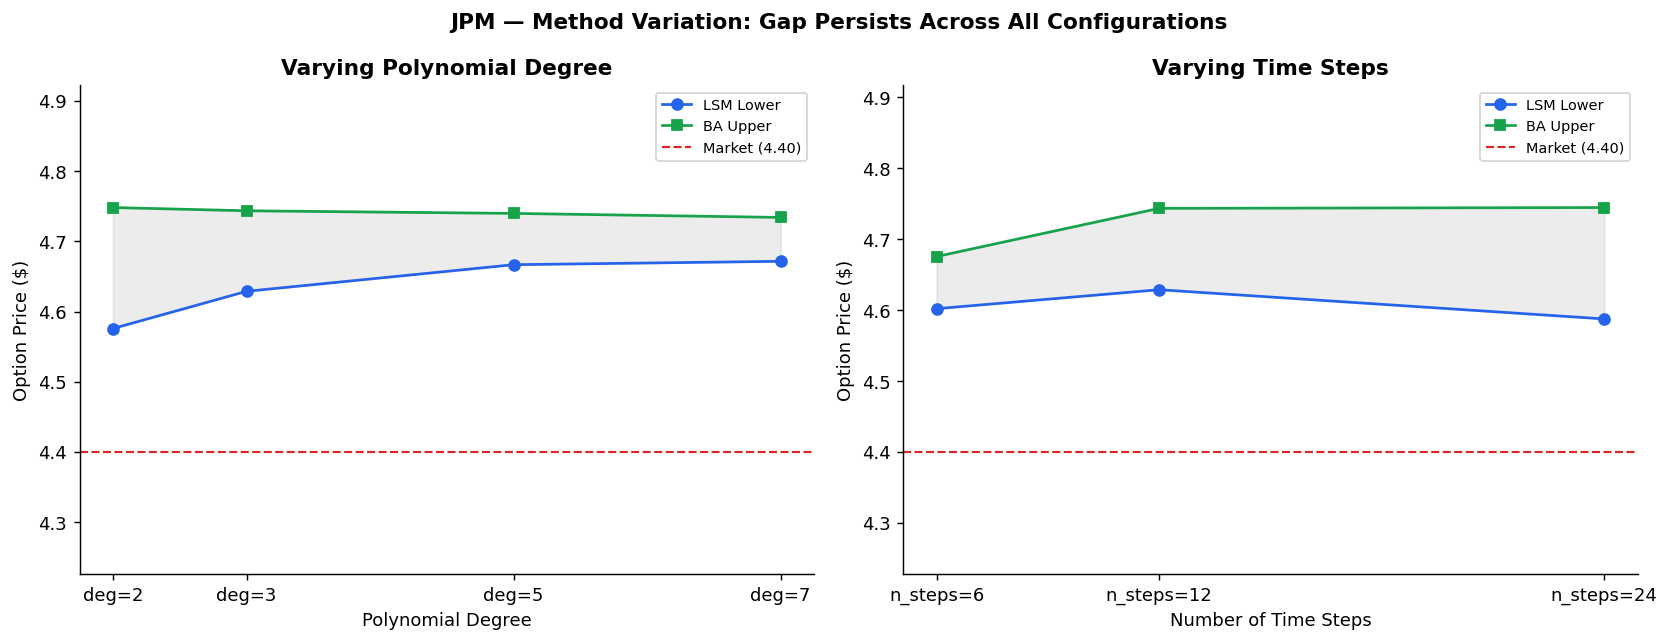

In [10]:
results, err_df = main_pipeline(data)

In [11]:
print("=" * 60)
print("DATA VERIFICATION")
print("=" * 60)

for ticker, d in data.items():
    spot   = d['spot']
    opts   = d['options']
    hist   = d['hist']
    
    print(f"\n[{ticker}]")
    print(f"  Spot price     : {spot:.2f}")
    print(f"  Options rows   : {len(opts)}")
    print(f"  Maturities     : {opts['T'].nunique()} unique")
    print(f"  T range        : {opts['T'].min():.3f} ~ {opts['T'].max():.3f}")
    print(f"  Strike range   : {opts['strike'].min():.2f} ~ {opts['strike'].max():.2f}")
    print(f"  IV range       : {opts['impl_volatility'].min():.3f} ~ {opts['impl_volatility'].max():.3f}")
    print(f"  IV nulls       : {opts['impl_volatility'].isna().sum()}")
    print(f"  Hist days      : {len(hist)}")
    print(f"  Hist nulls     : {hist['return'].isna().sum()}")
    
    atm = get_atm_iv_curve(opts, spot)
    print(f"  ATM IV curve   : {len(atm)} points")
    
    rv_30  = compute_rv(hist, 30)
    rv_252 = compute_rv(hist, 252)
    print(f"  RV 30d / 1y    : {rv_30:.3f} / {rv_252:.3f}")

print("\nData verification complete.")

DATA VERIFICATION

[SPY]
  Spot price     : 472.65
  Options rows   : 2636
  Maturities     : 33 unique
  T range        : 0.003 ~ 2.962
  Strike range   : 379.00 ~ 565.00
  IV range       : 0.080 ~ 1.138
  IV nulls       : 0
  Hist days      : 251
  Hist nulls     : 1
  ATM IV curve   : 33 points
  RV 30d / 1y    : 0.086 / 0.132

[NVDA]
  Spot price     : 481.68
  Options rows   : 724
  Maturities     : 19 unique
  T range        : 0.008 ~ 2.460
  Strike range   : 390.00 ~ 577.50
  IV range       : 0.273 ~ 1.044
  IV nulls       : 0
  Hist days      : 251
  Hist nulls     : 1
  ATM IV curve   : 19 points
  RV 30d / 1y    : 0.283 / 0.468

[TSLA]
  Spot price     : 248.42
  Options rows   : 407
  Maturities     : 18 unique
  T range        : 0.008 ~ 2.041
  Strike range   : 200.00 ~ 297.50
  IV range       : 0.429 ~ 1.267
  IV nulls       : 0
  Hist days      : 251
  Hist nulls     : 1
  ATM IV curve   : 18 points
  RV 30d / 1y    : 0.325 / 0.523

[JPM]
  Spot price     : 172.08
  Optio

In [14]:
def plot_vol_model_taxonomy():
    """
    Conceptual illustration of volatility dynamics across model families.
    Intended as the opening figure of Section 3.3 (Bridge to SLV & UVM).
    """
    np.random.seed(42)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('Volatility Dynamics Across Model Families',
                 fontsize=13, fontweight='bold')

    t = np.linspace(0, 1, 200)
    S = np.linspace(80, 120, 200)

    # Panel 1 — Black-Scholes: constant σ
    ax = axes[0]
    ax.axhline(0.22, color=COLORS['SPY'], linewidth=2.2)
    ax.set_title('Black-Scholes\nσ = const', fontweight='bold')
    ax.set_xlabel('t')
    ax.set_ylabel('σ')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

    # Panel 2 — Local Volatility: deterministic σ(S, t)
    ax = axes[1]
    sigma_lv = 0.35 - 0.18 * np.exp(-((S - 100) / 10) ** 2) \
           + 0.05 * (1 - S / 120)
    ax.plot(S, sigma_lv, color=COLORS['NVDA'], linewidth=2.2)
    ax.axvline(100, color='gray', linestyle='--', linewidth=0.8, label='ATM')
    ax.set_title('Local Volatility\nσ(S, t)', fontweight='bold')
    ax.set_xlabel('S')
    ax.set_ylabel('σ')
    ax.set_ylim(0, 0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(loc='upper right', fontsize=8, frameon=False)

    # Panel 3 — Stochastic Volatility: mean-reverting random paths
    ax = axes[2]
    n_paths = 12
    kappa, theta, xi = 3.0, 0.22, 0.25
    dt = t[1] - t[0]
    for _ in range(n_paths):
        v = np.zeros_like(t)
        v[0] = 0.22
        for i in range(1, len(t)):
            dW = np.random.standard_normal() * np.sqrt(dt)
            v[i] = max(v[i-1] + kappa * (theta - v[i-1]) * dt
                       + xi * np.sqrt(max(v[i-1], 0)) * dW, 1e-4)
        ax.plot(t, v, color=COLORS['TSLA'], alpha=0.35, linewidth=1.1)
    ax.axhline(theta, color='gray', linestyle='--', linewidth=1.0, label='θ')
    ax.set_title('Stochastic Volatility\n$dv_t = κ(θ − v_t)dt + ξ\\sqrt{v_t}\\,dW_t$',
                 fontweight='bold')
    ax.set_xlabel('t')
    ax.set_ylabel('σ')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(loc='upper right', fontsize=8, frameon=False)

    # Panel 4 — UVM: band + worst-case bang-bang path
    ax = axes[3]
    sigma_min, sigma_max = 0.15, 0.32
    ax.fill_between(t, sigma_min, sigma_max, color=COLORS['JPM'],
                    alpha=0.18, label=r'[$σ_{min}, σ_{max}$]')
    # Bang-bang worst-case switching
    switch = (np.sin(4 * np.pi * t) > 0).astype(float)
    worst_case = sigma_min + (sigma_max - sigma_min) * switch
    ax.step(t, worst_case, where='post',
            color=COLORS['JPM'], linewidth=2.2, label='worst-case σ')
    ax.axhline(sigma_max, color='gray', linestyle=':', linewidth=0.8)
    ax.axhline(sigma_min, color='gray', linestyle=':', linewidth=0.8)
    ax.set_title('Uncertain Volatility\n$σ_t ∈ [σ_{min}, σ_{max}]$',
                 fontweight='bold')
    ax.set_xlabel('t')
    ax.set_ylabel('σ')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(loc='upper right', fontsize=8, frameon=False)

    plt.tight_layout()
    plt.show()

3.3 — Bridge to SLV & UVM


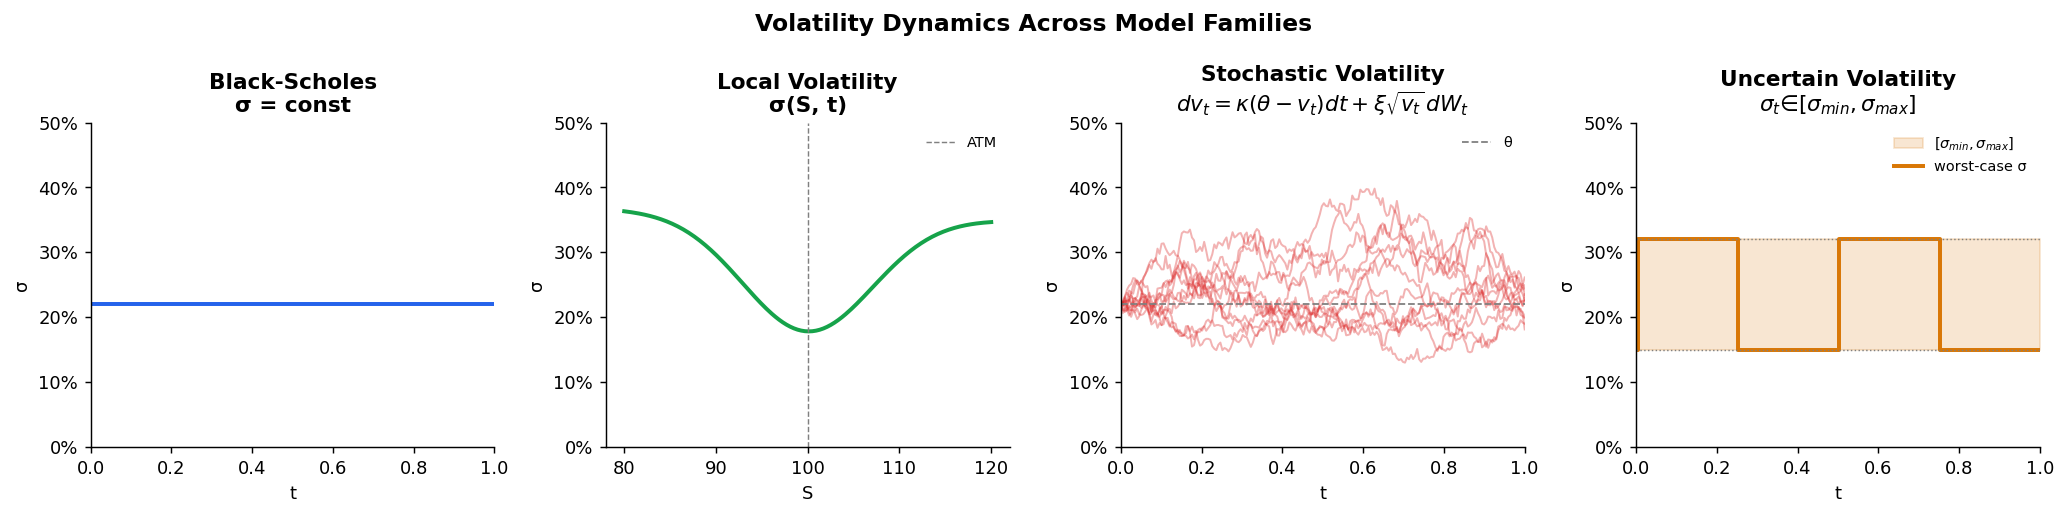

In [15]:
print("=" * 60)
print("3.3 — Bridge to SLV & UVM")
print("=" * 60)

plot_vol_model_taxonomy()